# **Customer Value Prediction and Market Basket Analysis using Data Mining**

1. Environment Setup and Data Preprocessing

In [1]:
!pip install mlxtend openpyxl seaborn

In [23]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the UCI Online Retail Dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

# 1. Data Cleaning

df.dropna(subset=['CustomerID'], inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 2. Aggregation at Customer Level

df['TotalSpend'] = df['Quantity'] * df['UnitPrice']
customer_df = df.groupby('CustomerID').agg({
    'TotalSpend': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'
}).rename(columns={'InvoiceNo': 'Frequency'})

# 3. Binary Label Creation

median_spend = customer_df['TotalSpend'].median()
customer_df['Label'] = (customer_df['TotalSpend'] > median_spend).astype(int)

# 4. Train/Test Split


X = customer_df[['Quantity', 'Frequency']]
y = customer_df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset processed. Training shape: {X_train.shape}, Test shape: {X_test.shape}")

Dataset processed. Training shape: (3470, 2), Test shape: (868, 2)


2. Jackknife Estimator

In [4]:
def jackknife_mean_estimate(data):
    n = len(data)
    jack_means = []

    # Iterate through data, leaving one observation out at a time
    for i in range(n):
        resample = np.delete(data, i)
        jack_means.append(resample.mean())

    usual_estimate = np.mean(data)
    jackknife_estimate = np.mean(jack_means)
    return usual_estimate, jackknife_estimate

# Compare estimates using a sample of the data
sample_data = customer_df['TotalSpend'].values[:100]
usual, jack = jackknife_mean_estimate(sample_data)

print(f"Usual Mean Estimate: {usual:.2f}")
print(f"Jackknife Mean Estimate: {jack:.2f}")

Usual Mean Estimate: 4101.38
Jackknife Mean Estimate: 4101.38


3. Classification (Naive Bayes & KNN)

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Naive Bayes [cite: 25]
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# KNN with different k values [cite: 26]
k_values = [3, 5, 7]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_results[f"KNN (k={k})"] = knn.predict(X_test)

print("Naive Bayes and KNN models trained.")

Naive Bayes and KNN models trained.


4. Model Evaluation

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, name):
    print(f"\nEvaluation for {name}:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

# Evaluate Naive Bayes
evaluate_model(y_test, nb_preds, "Naive Bayes")

# Evaluate KNN (example k=5)
evaluate_model(y_test, knn_results["KNN (k=5)"], "KNN (k=5)")


Evaluation for Naive Bayes:
Accuracy:  0.8180
Precision: 0.9795
Recall:    0.6538
F1-Score:  0.7842
Confusion Matrix:
[[423   6]
 [152 287]]

Evaluation for KNN (k=5):
Accuracy:  0.8882
Precision: 0.8995
Recall:    0.8770
F1-Score:  0.8881
Confusion Matrix:
[[386  43]
 [ 54 385]]


         Model  Accuracy  Precision  Recall      F1
0  Naive Bayes    0.8180     0.9795  0.6538  0.7842
1    KNN (k=5)    0.8882     0.8995  0.8770  0.8881


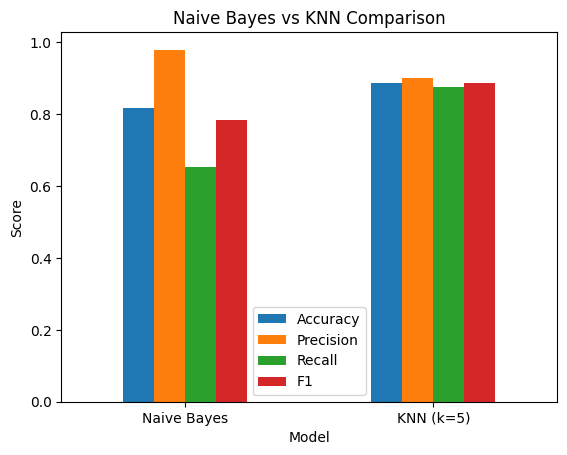

In [24]:
results = [
    {"Model": "Naive Bayes", "Accuracy": 0.8180, "Precision": 0.9795, "Recall": 0.6538, "F1": 0.7842},
    {"Model": "KNN (k=5)", "Accuracy": 0.8882, "Precision": 0.8995, "Recall": 0.8770, "F1": 0.8881}
]

results_df = pd.DataFrame(results)

print(results_df)

#  Bar Chart
results_df.set_index("Model").plot(kind='bar')
plt.title("Naive Bayes vs KNN Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

| Metric    | Naive Bayes | KNN (k=5) | Winner |
| --------- | ----------- | --------- | ------ |
| Accuracy  | 0.818       | **0.888** | KNN    |
| Precision | **0.979**   | 0.899     | NB     |
| Recall    | 0.654       | **0.877** | KNN    |
| F1-score  | 0.784       | **0.888** | KNN    |


Comparison of Naive Bayes and KNN Performance

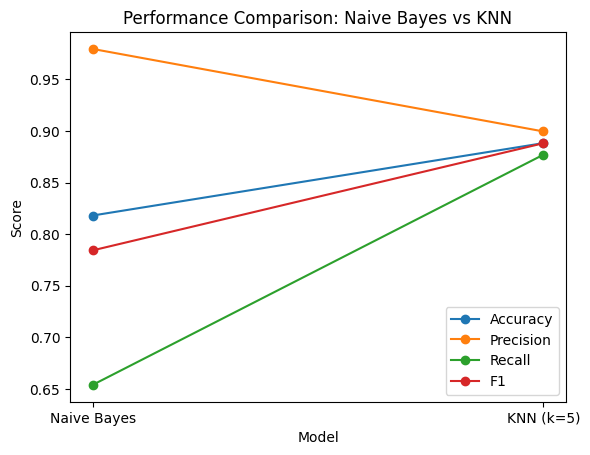

In [26]:
plt.figure()

for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    plt.plot(results_df["Model"], results_df[metric], marker='o', label=metric)

plt.legend()
plt.title("Performance Comparison: Naive Bayes vs KNN")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

Confusion Matrix for Naive Bayes


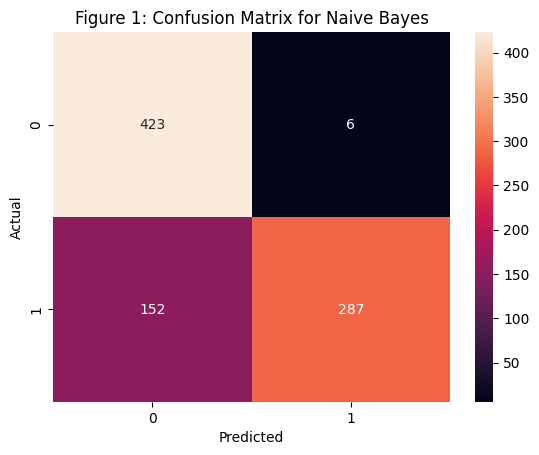

In [27]:
# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, nb_preds)

plt.figure()
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Figure 1: Confusion Matrix for Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix for KNN (k=5)

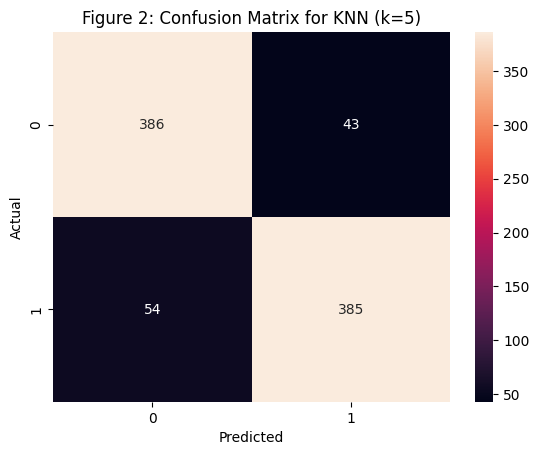

In [28]:
cm_knn = confusion_matrix(y_test, knn_results["KNN (k=5)"])

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Figure 2: Confusion Matrix for KNN (k=5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

5. Tree-Based Models

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree_models = {
    "Decision Tree (Gini/CART)": DecisionTreeClassifier(criterion='gini'),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in tree_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    evaluate_model(y_test, preds, name)


Evaluation for Decision Tree (Gini/CART):
Accuracy:  0.8825
Precision: 0.9041
Recall:    0.8588
F1-Score:  0.8808
Confusion Matrix:
[[389  40]
 [ 62 377]]

Evaluation for Random Forest:
Accuracy:  0.8790
Precision: 0.8920
Recall:    0.8656
F1-Score:  0.8786
Confusion Matrix:
[[383  46]
 [ 59 380]]


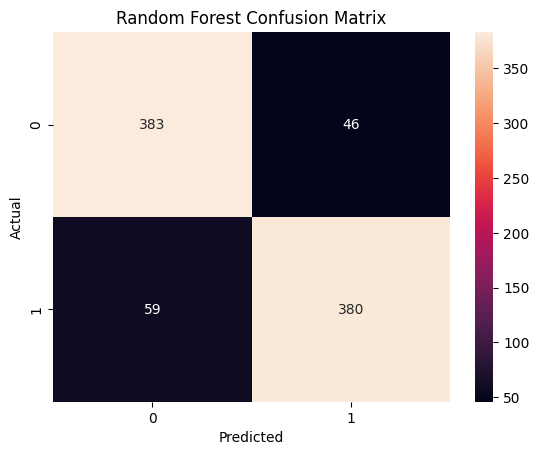

In [9]:
    cm = confusion_matrix(y_test, preds)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

           Model  Accuracy  Precision  Recall      F1
0  Decision Tree    0.8825     0.9041  0.8588  0.8808
1  Random Forest    0.8790     0.8920  0.8656  0.8786


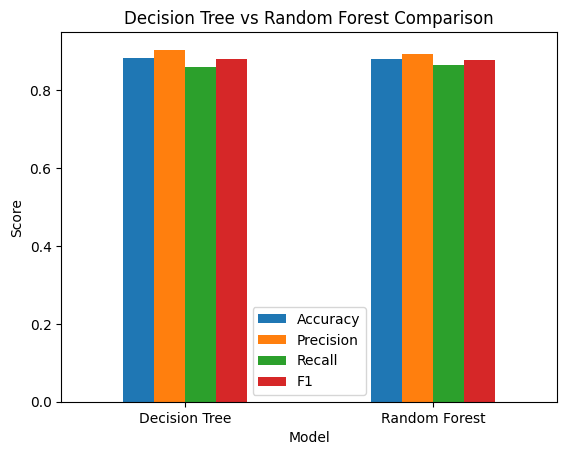

In [30]:
results = [
    {"Model": "Decision Tree", "Accuracy": 0.8825, "Precision": 0.9041, "Recall": 0.8588, "F1": 0.8808},
    {"Model": "Random Forest", "Accuracy": 0.8790, "Precision": 0.8920, "Recall": 0.8656, "F1": 0.8786}
]

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print(results_df)

#  Bar Chart
results_df.set_index("Model").plot(kind='bar')
plt.title("Decision Tree vs Random Forest Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

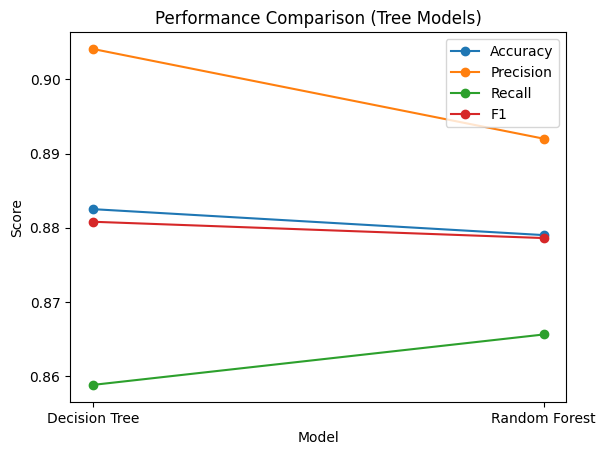

In [12]:
plt.figure()

for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    plt.plot(results_df["Model"], results_df[metric], marker='o', label=metric)

plt.legend()
plt.title("Performance Comparison (Tree Models)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

| Metric    | Better Model  | Why it matters                  |
| --------- | ------------- | ------------------------------- |
| Accuracy  | Decision Tree | Overall correctness             |
| Precision | Decision Tree | Avoids false positives          |
| Recall    | Random Forest | Finds more high-value customers |
| F1-score  | Decision Tree | Balanced performance            |


6. Clustering

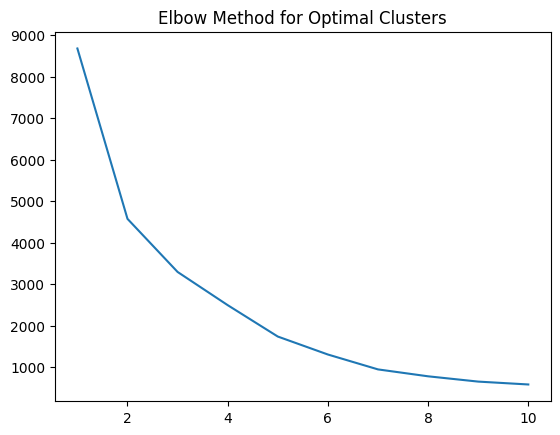

Clustering complete.


In [8]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# Feature Scaling (Crucial for Clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
# Using the Elbow Method to determine optimal clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal Clusters')
plt.show()

# Additional Method: Agglomerative Clustering
agg_cluster = AgglomerativeClustering(n_clusters=3)
customer_df['Cluster_Label'] = agg_cluster.fit_predict(X_scaled)
print("Clustering complete.")

7. Association Rules

In [31]:
from mlxtend.frequent_patterns import apriori, association_rules

# Pivot data to transaction format
basket = (df[df['Country'] == "United Kingdom"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Encode as 0/1
def encode_units(x):
    return 1 if x >= 1 else 0

basket_sets = basket.map(encode_units)

# Frequent Itemsets and Rules
frequent_itemsets = apriori(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("Top Association Rules Found:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Top Association Rules Found:
                 antecedents                consequents   support  confidence  \
0  (JUMBO BAG RED RETROSPOT)  (JUMBO BAG PINK POLKADOT)  0.030398    0.349689   
1  (JUMBO BAG PINK POLKADOT)  (JUMBO BAG RED RETROSPOT)  0.030398    0.623153   

       lift  
0  7.168625  
1  7.168625  


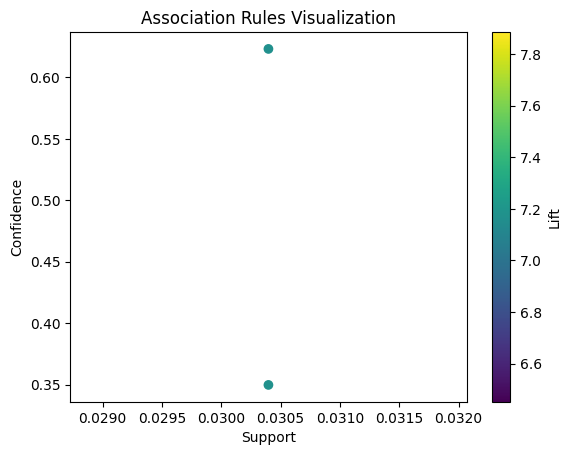

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules Visualization')
plt.show()

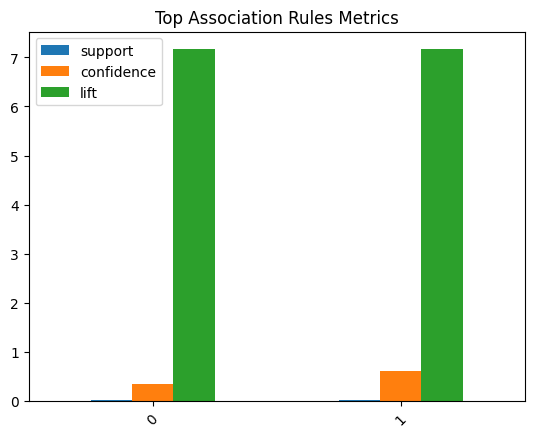

In [33]:
top_rules = rules.sort_values(by='lift', ascending=False).head(5)

top_rules[['support', 'confidence', 'lift']].plot(kind='bar')
plt.title("Top Association Rules Metrics")
plt.xticks(rotation=45)
plt.show()

# Thank You

### *A Journey Through Data, Insight, and Discovery*

This project is more than just code, models, and metrics—
it represents a meaningful step in my journey as a data scientist.

---

## Gratitude

I would like to express my sincere appreciation to:

* **Prof. Dr. Md. Rezaul Karim**
  For providing clear guidance, challenging tasks, and the opportunity to explore real-world data mining techniques.

---

##  What This Project Represents

Through this work, I have:

* Transformed raw data into meaningful insights
* Explored multiple machine learning techniques
* Understood the importance of evaluation, validation, and interpretation
* Learned how data can drive real-world decisions

---

##  Looking Ahead

I look forward to:

* Building more intelligent systems
* Solving real-world problems
* Continuously learning and evolving in the field of data science

---


### Submitted By

# **Forkan Amin**

20251610

*M.Sc. in Applied Statistics & Data Science*

---

*Thank you for taking the time to review this work.*
